# 02 · Partición temporal

Una sola definición para todo el proyecto, en `src/particion.py`:

- **OOT**: últimos 4 meses observados. Se evalúa una sola vez con el modelo final (metodología §4.3).
- **Desarrollo**: todo lo anterior al OOT menos 6 meses de brecha (= horizonte de churn), para que ninguna
  etiqueta de desarrollo mire dentro del OOT.
- **Validación**: 4 bloques consecutivos de 4 meses al final del desarrollo; cada bloque entrena con toda la
  historia previa menos la misma brecha de 6 meses (ventana expansiva). La métrica de selección es la media del
  AUC de los 4 bloques.

Esta celda escribe `02_particion/particion.json` con las fechas efectivas, que leen las fases siguientes.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import datos, particion
pd.set_option("display.width", 160)
df = datos.load()
FEATS = datos.features(df)
print(df.shape, "| variables:", len(FEATS))

(31235, 46) | variables: 42


In [2]:
tabla = particion.describe(df)
tabla

,bloque,train_desde,train_hasta,val_desde,val_hasta,n_train,n_val,churn_val
0,val_1,2016-12,2023-07,2024-02,2024-05,23426,1006,0.2833
1,val_2,2016-12,2023-11,2024-06,2024-09,24594,1110,0.2793
2,val_3,2016-12,2024-03,2024-10,2025-01,25637,1039,0.3282
3,val_4,2016-12,2024-07,2025-02,2025-05,26695,872,0.3177
4,oot,2016-12,2025-05,2025-12,2026-03,29183,879,0.2765


## Línea de tiempo

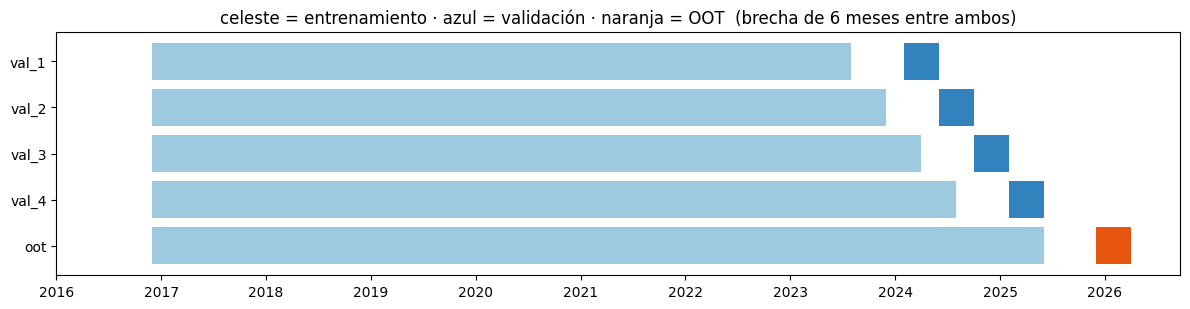

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.2))
to_num = lambda s: pd.Period(s, "M").ordinal
for i, r in tabla.iterrows():
    ax.barh(i, to_num(r.train_hasta) - to_num(r.train_desde) + 1, left=to_num(r.train_desde), color="#9ecae1")
    ax.barh(i, to_num(r.val_hasta) - to_num(r.val_desde) + 1, left=to_num(r.val_desde),
            color="#e6550d" if r.bloque == "oot" else "#3182bd")
ax.set_yticks(range(len(tabla))); ax.set_yticklabels(tabla.bloque); ax.invert_yaxis()
ticks = [to_num(f"{y}-01") for y in range(df.mes_obs.dt.year.min(), df.mes_obs.dt.year.max() + 1)]
ax.set_xticks(ticks); ax.set_xticklabels([str(pd.Period(ordinal=t, freq="M").year) for t in ticks])
ax.set_title("celeste = entrenamiento · azul = validación · naranja = OOT  (brecha de 6 meses entre ambos)")
plt.tight_layout(); plt.show()

## Verificación y exportación

In [4]:
import json
dev, oot = particion.oot_split(df.mes_rank)
assert df[dev].mes_rank.max() + particion.GAP < df[oot].mes_rank.min()
assert not (dev & oot).any() and (dev | oot).sum() < len(df)  # la brecha queda fuera de ambos
print(f"desarrollo: {dev.sum():,} filas | brecha: {(~dev & ~oot).sum():,} | oot: {oot.sum():,}")

spec = {"gap": particion.GAP, "oot_months": particion.OOT_MONTHS, "n_folds": particion.N_FOLDS,
        "fold_months": particion.FOLD_MONTHS, "n_filas": len(df),
        "bloques": tabla.to_dict(orient="records")}
(Path.cwd() / "particion.json").write_text(json.dumps(spec, indent=2, ensure_ascii=False))
print("-> particion.json")

desarrollo: 29,183 filas | brecha: 1,173 | oot: 879
-> particion.json
